In [ ]:
# Dimensionality Reduction Techniques :

# decrease the number of features(dimensions) in a dataset
# -> preserve as much of information as possible
# Why? - too many features -> model becomes too complex
# -> performance descrease, difficult to visualise data
# -> simplify the model - reduce dimensions

# Advs :
# improved comptational efficiency - cost reduced 
# reduce noise -> extra(irrelavant, noisy) features removed
# enhanced visualisation - less features
# boost model performance
# save storage and memory

# Approaches :

# 1. Feature Selection :
# -> process - choose a subset of releavant feature
# -> Filter Methods : Correlation, ChiSqaure test
# -> Wrapper Methods : Fwd and backward selection techniques
# -> Embedded Methods : LASSO, Ridge, Elastic Net

# 2. Feature Extraction :
# -> process of transforming high dimensional data into a lower dimenisonal space
# -> many features ->  less features
# -> preserve / retain all essential information 
# Common Techniques
# 1. PCA - Principal Component Analysis
# 2. LDA - Linear Discriminant Analysis
# 3. ICA - Independent Component Analysis


In [ ]:
# PCA
# Orthogonality : each principal component is perpendicluar (independent) to ervery othe component
# Feature : how values are spread for that particular from the mean value
# dataset -> 20 features -> PCA -> 8 new features - principal components - linear combination  of the original features


In [1]:
# Implement PCA
import pandas as pd

# Load the dataset 
data = pd.read_csv('diabetes.csv')
data.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6.0,159.1,67.5,27.0,408.6,57.0,0.642,36.0,tested_negative
1,14.0,170.3,111.6,30.0,758.4,65.6,1.157,53.0,tested_positive
2,10.0,139.3,88.5,83.5,831.3,46.2,1.204,23.0,tested_positive
3,7.0,150.6,24.8,49.6,337.6,29.0,1.391,43.0,tested_positive
4,6.0,102.2,116.4,51.8,351.5,60.4,1.993,31.0,tested_positive


In [3]:
# Split this into features and target
X = data.drop(columns=['class'])
y = data['class'].apply(lambda x:1 if x=='tested_positive' else 0)
y.head()

0    0
1    1
2    1
3    1
4    1
Name: class, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Standarize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Apply PCA
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
pca = PCA()
pca.fit(X_train_scaled)
# variance ratios
explained_variance = pca.explained_variance_ratio_  # mx variance in your data

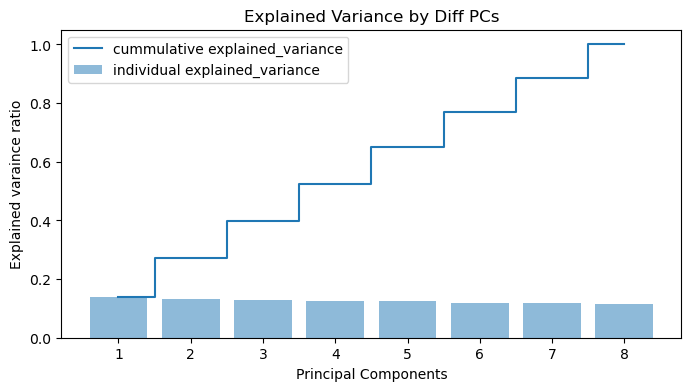

In [15]:
plt.figure(figsize=(8,4))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5,
        align='center', label='individual explained_variance')
plt.step(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), where='mid',
         label='cummulative explained_variance')
plt.xlabel('Principal Components')
plt.ylabel('Explained varaince ratio')
plt.title('Explained Variance by Diff PCs')
plt.legend()
plt.show()

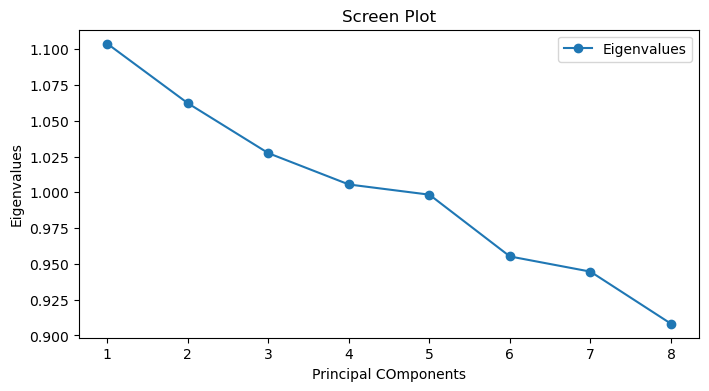

In [17]:
# Eigenvalues - proportional to explained_variance_
eigenvalues = pca.explained_variance_
plt.figure(figsize=(8,4))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='-', label='Eigenvalues')
plt.xlabel("Principal COmponents")
plt.ylabel('Eigenvalues')
plt.title('Screen Plot')
plt.legend()
plt.show()

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca = PCA(n_components=3)
X_train_pca =  pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [29]:
# Create dfs
df_train_pca = pd.DataFrame(data=X_train_pca, columns=['Prinicipal Compoenent 1','Prinicipal Compoenent 2',
                                                       'Prinicipal Compoenent 3'])
df_train_pca['Target'] = y_train

df_test_pca = pd.DataFrame(data=X_test_pca, columns=['Prinicipal Compoenent 1','Prinicipal Compoenent 2',
                                                       'Prinicipal Compoenent 3'])
df_test_pca['Target'] = y_test                            

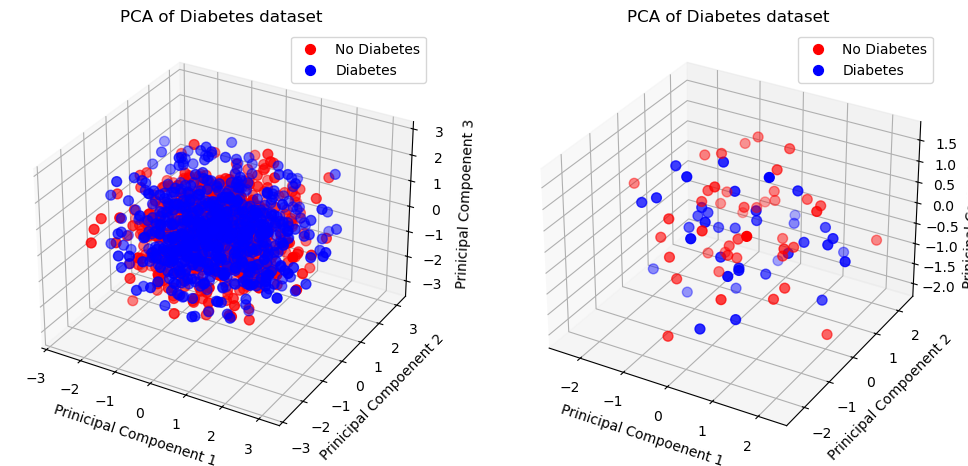

In [35]:
# plot 3d scatter plot
fig = plt.figure(figsize=(12,8))
# training Set
ax1 = fig.add_subplot(121, projection='3d') # 121 -> 1 row 2 cols 1st subplot
colors = ['r','b']
for target, color in zip([0,1], colors):
    indices = df_train_pca['Target'] == target
    ax1.scatter(df_train_pca.loc[indices, 'Prinicipal Compoenent 1'],
                df_train_pca.loc[indices, 'Prinicipal Compoenent 2'],
                df_train_pca.loc[indices, 'Prinicipal Compoenent 3'],
                c=color, s=50)
ax1.set_xlabel('Prinicipal Compoenent 1')
ax1.set_ylabel('Prinicipal Compoenent 2')
ax1.set_zlabel('Prinicipal Compoenent 3')
ax1.legend(['No Diabetes', 'Diabetes'])
ax1.set_title('PCA of Diabetes dataset')
ax1.grid()
# testing Set
ax2 = fig.add_subplot(122, projection='3d') # # 122 -> 1 row 2 cols 2nd subplot
for target, color in zip([0,1], colors):
    indices = df_test_pca['Target'] == target
    ax2.scatter(df_test_pca.loc[indices, 'Prinicipal Compoenent 1'],
                df_test_pca.loc[indices, 'Prinicipal Compoenent 2'],
                df_test_pca.loc[indices, 'Prinicipal Compoenent 3'],
                c=color, s=50)
ax2.set_xlabel('Prinicipal Compoenent 1')
ax2.set_ylabel('Prinicipal Compoenent 2')
ax2.set_zlabel('Prinicipal Compoenent 3')
ax2.legend(['No Diabetes', 'Diabetes'])
ax2.set_title('PCA of Diabetes dataset')
ax2.grid()
plt.show()